In [2]:

import torch
import numpy as np

# Global variable to track communication cost in bytes
communication_log = []

def compute_communication_cost(tensor, data_type_size=4):
    # data_type_size=4 for float32
    if isinstance(tensor, dict):
        size = sum(param.numel() for param in tensor.values())
    else:
        size = tensor.numel()
    return size * data_type_size


In [3]:

def top_k_sparsify(tensor, k=1000):
    flat = tensor.flatten()
    if flat.numel() <= k:
        return tensor
    values, indices = torch.topk(flat.abs(), k)
    mask = torch.zeros_like(flat)
    mask[indices] = 1
    sparse_tensor = (flat * mask).reshape(tensor.shape)
    return sparse_tensor

def quantize_tensor(tensor, num_bits=8):
    qmin = 0.
    qmax = 2.**num_bits - 1.
    min_val, max_val = tensor.min(), tensor.max()
    scale = (max_val - min_val) / (qmax - qmin)
    quantized = ((tensor - min_val) / scale).round().clamp(qmin, qmax)
    return quantized


In [4]:

def log_and_update(user_model, neighbor_models, k=1000, quantize=False):
    global communication_log
    # Peer-to-peer model averaging (e.g., gossip-style)
    neighbor_avg = sum(neighbor_models) / len(neighbor_models)

    # Log outgoing communication
    for neighbor_model in neighbor_models:
        delta = user_model - neighbor_model
        sparse_delta = top_k_sparsify(delta, k)
        if quantize:
            sparse_delta = quantize_tensor(sparse_delta)
        cost = compute_communication_cost(sparse_delta)
        communication_log.append(cost)
    
    # Update user model
    user_model = 0.5 * user_model + 0.5 * neighbor_avg
    return user_model


In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import gc
from itertools import product
from sklearn.model_selection import train_test_split

In [6]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main/code
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [7]:
from src.models.MatrixFactorization import MF, UMF
from src.graphs import random_k_out_graph, create_graph
from src.users import User
from src.training.decentralized import decentralized_train_loop, decentralized_validate_loop, decentralized_train_n_epochs
from src.data_utils import create_batched_dataloaders, create_dataloader

In [8]:
class SparseFastNeighborDMF_NX:
    def __init__(self, num_users, num_items, latent_dim=10, lr=0.01,
                 alpha=0.01, beta=0.01, gamma=0.01, top_k=10):
        self.num_users = num_users
        self.num_items = num_items
        self.latent_dim = latent_dim
        self.lr = lr
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.top_k = top_k
        self.comm_cost = {u: {'sent': 0, 'recv': 0} for u in range(self.num_users)}

        self.user_factors = np.random.normal(scale=0.1, size=(num_users, latent_dim))
        self.common_item_factors = np.random.normal(scale=0.1, size=(num_items, latent_dim))
        self.personal_item_factors = {}  # (user_id, item_id) -> latent vector
        self.neighbors = {}

        # New logs
        self.epoch_times = []
        self.gradient_sharing_counts = []

    def build_neighbors_networkx(self, data, graph):
        if(sum(np.isnan(graph))):
            G = nx.Graph()
            item_user_map = {}

            for user_id, item_id, _ in data:
                item_user_map.setdefault(item_id, set()).add(user_id)

            for users in item_user_map.values():
                for u in users:
                    for v in users:
                        if u != v:
                            G.add_edge(u, v)
        else:
            G = graph

        for user_id in range(self.num_users):
            neighbors = list(G.neighbors(user_id)) if user_id in G else []
            if len(neighbors) > self.top_k:
                neighbors = np.random.choice(neighbors, size=self.top_k, replace=False)
            self.neighbors[user_id] = neighbors

    def train(self, data, val_data=None, epochs=100, patience=5, time_threshold=60):
        import time
    
        self.epoch_times = []
        self.gradient_sharing_counts = []
        self.train_losses = []
        self.val_losses = []
        epoch_summary = {}
    
        best_val_loss = float('inf')
        no_improve_count = 0
    
        for epoch in range(epochs):
            start_time = time.time()
            gradient_sharing_count = 0
            mse_train = 0.0
    
            np.random.shuffle(data)
            for user_id, item_id, rating in data:
                u = self.user_factors[user_id]
                p = self.common_item_factors[item_id]
                q_key = (user_id, item_id)
                if q_key not in self.personal_item_factors:
                    self.personal_item_factors[q_key] = np.random.normal(scale=0.1, size=self.latent_dim)
                q = self.personal_item_factors[q_key]
    
                pred = np.dot(u, p + q)
                error = rating - pred
                mse_train += error ** 2
    
                grad_u = -error * (p + q) + self.alpha * u
                grad_p = -error * u + self.beta * p
                grad_q = -error * u + self.gamma * q
    
                self.user_factors[user_id] -= self.lr * grad_u
                self.personal_item_factors[q_key] -= self.lr * grad_q
    
                for neighbor_id in self.neighbors.get(user_id, []):
                    self.common_item_factors[item_id] -= self.lr * grad_p / max(1, len(self.neighbors[user_id]))
                    gradient_sharing_count += 1
    
            epoch_time = time.time() - start_time
            rmse_train = np.sqrt(mse_train / len(data))
    
            # Validation loss
            if val_data is not None:
                mse_val = 0.0
                for user_id, item_id, rating in val_data:
                    pred = self.predict(user_id, item_id)
                    mse_val += (rating - pred) ** 2
                rmse_val = np.sqrt(mse_val / len(val_data))
            else:
                rmse_val = None
    
            # Store logs
            self.epoch_times.append(epoch_time)
            self.gradient_sharing_counts.append(gradient_sharing_count)
            self.train_losses.append(rmse_train)
            self.val_losses.append(rmse_val)
            epoch_summary[epoch] = {
                'time': epoch_time,
                'gradient_sharing': gradient_sharing_count,
                'train_rmse': rmse_train,
                'val_rmse': rmse_val
            }
    
           
            # Early stopping rules
            if rmse_val is not None:
                if rmse_val < best_val_loss:
                    best_val_loss = rmse_val
                    no_improve_count = 0
                else:
                    no_improve_count += 1
    
                if no_improve_count >= patience:
                    print(f"Early stopping: No improvement in validation loss for {patience} epochs.")
                    break
    
            if epoch_time > time_threshold:
                print(f"Early stopping: Epoch time exceeded {time_threshold} seconds.")
                break
    
        return epoch_summary
        
    def predict(self, user_id, item_id):
        u = self.user_factors[user_id]
        p = self.common_item_factors[item_id]
        q_key = (user_id, item_id)
        q = self.personal_item_factors.get(q_key, np.zeros(self.latent_dim))
        return np.dot(u, p + q)

    def compute_rmse(self, data):
        mse = 0.0
        for user_id, item_id, rating in data:
            pred = self.predict(user_id, item_id)
            mse += (rating - pred) ** 2
        return np.sqrt(mse / len(data))

In [9]:
train_df = pd.read_csv("dataset/ml-1m_train.csv")
test_df = pd.read_csv("dataset/ml-1m_test.csv")
train_df.head()

n_users = train_df['user_id'].nunique()
n_items = train_df['item_id'].nunique()
print(f"Total User: {n_users}")
print(f"Total Item: {n_items}")

train_sub_df, val_sub_df = train_test_split(train_df, test_size=0.2, random_state=42)

# Convert to tuples for training
train_tuples = list(train_sub_df[["user_id", "item_id", "rating"]].itertuples(index=False, name=None))
val_tuples = list(val_sub_df[["user_id", "item_id", "rating"]].itertuples(index=False, name=None))

# test_df remains as your final test set
test_tuples = list(test_df[["user_id", "item_id", "rating"]].itertuples(index=False, name=None))

Total User: 6040
Total Item: 3664


In [10]:
# Grid search setup
latent_dims = [8, 10, 16]
lrs = [0.001, 0.005, 0.01]
top_ks = [5, 10, 15]
epochs = 50

# Evaluation storage
best_rmse = float("inf")
best_config = None
results = []

graph = create_graph( "random_2_out", n_users=n_users,seed=1)  
for dim, lr, k in product(latent_dims, lrs, top_ks):
    print(f"\nTraining config: latent_dim={dim}, lr={lr}, top_k={k}")
    
    model = SparseFastNeighborDMF_NX(
        num_users=n_users,
        num_items=n_items,
        latent_dim=dim,
        lr=lr,
        top_k=k
    )
    model.build_neighbors_networkx(train_tuples, graph)
    model.train(train_tuples, val_data=val_tuples, epochs=epochs, patience=5, time_threshold=30)
    
    val_rmse = model.compute_rmse(val_tuples)
    results.append((dim, lr, k, val_rmse))
    
    print(f"Validation RMSE: {val_rmse:.4f}")
    if val_rmse < best_rmse:
        best_rmse = val_rmse
        best_config = (dim, lr, k)
    
    del model
    gc.collect()

print("\nBest configuration:")
print(f"latent_dim={best_config[0]}, lr={best_config[1]}, top_k={best_config[2]}, RMSE={best_rmse:.4f}")


Training config: latent_dim=8, lr=0.001, top_k=5
Validation RMSE: 0.9140

Training config: latent_dim=8, lr=0.001, top_k=10
Validation RMSE: 0.9125

Training config: latent_dim=8, lr=0.001, top_k=15
Validation RMSE: 0.9165

Training config: latent_dim=8, lr=0.005, top_k=5
Validation RMSE: 0.8915

Training config: latent_dim=8, lr=0.005, top_k=10
Validation RMSE: 0.8898

Training config: latent_dim=8, lr=0.005, top_k=15
Validation RMSE: 0.8926

Training config: latent_dim=8, lr=0.01, top_k=5
Validation RMSE: 0.8882

Training config: latent_dim=8, lr=0.01, top_k=10
Validation RMSE: 0.8892

Training config: latent_dim=8, lr=0.01, top_k=15
Validation RMSE: 0.8886

Training config: latent_dim=10, lr=0.001, top_k=5
Validation RMSE: 0.9178

Training config: latent_dim=10, lr=0.001, top_k=10
Validation RMSE: 0.9173

Training config: latent_dim=10, lr=0.001, top_k=15
Validation RMSE: 0.9208

Training config: latent_dim=10, lr=0.005, top_k=5
Validation RMSE: 0.8906

Training config: latent_dim=

In [35]:
full_train_tuples = list(train_df[["user_id", "item_id", "rating"]].itertuples(index=False, name=None))
test_tuples = list(test_df[["user_id", "item_id", "rating"]].itertuples(index=False, name=None))

best_model = SparseFastNeighborDMF_NX(
    num_users=n_users,
    num_items=n_items,
    latent_dim=best_config[0],
    lr=best_config[1],
    top_k=best_config[2]
)
best_model.build_neighbors_networkx(full_train_tuples, graph)
best_model.train(full_train_tuples, val_data=test_tuples, epochs=50)

test_rmse = best_model.compute_rmse(test_tuples)
print(f"Test RMSE (best model): {test_rmse:.4f}")

Test RMSE (best model): 0.8749


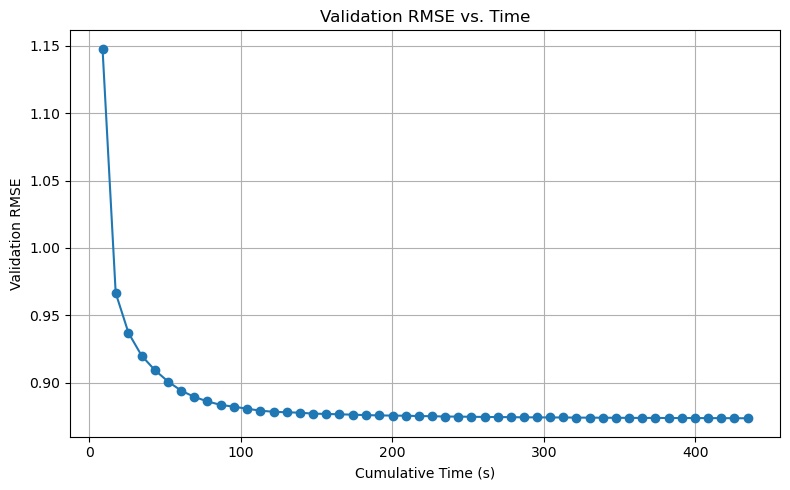

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Compute cumulative time
cumulative_time = np.cumsum(best_model.epoch_times)

# Plot validation RMSE vs. cumulative training time
plt.figure(figsize=(8, 5))
plt.plot(cumulative_time, best_model.val_losses, marker='o')
plt.xlabel("Cumulative Time (s)")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs. Time")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
best_model.epoch_times

[8.715901136398315,
 8.68505859375,
 8.452500343322754,
 8.719558000564575,
 8.757196187973022,
 8.852772951126099,
 8.511805295944214,
 8.665916204452515,
 8.57099986076355,
 8.711628913879395,
 8.586267709732056,
 8.792768001556396,
 8.842204332351685,
 8.765095233917236,
 8.724186182022095,
 8.69974398612976,
 8.577835083007812,
 8.700825929641724,
 8.755034923553467,
 8.71363377571106,
 9.053161144256592,
 8.659903049468994,
 8.716992139816284,
 8.777766942977905,
 8.449804782867432,
 8.588048219680786,
 8.680356979370117,
 8.740585088729858,
 8.704478025436401,
 8.932921171188354,
 8.53902292251587,
 8.49587082862854,
 8.54781198501587,
 8.708293914794922,
 8.638195991516113,
 8.60531497001648,
 8.858139991760254,
 8.687500953674316,
 8.62690782546997,
 8.81098222732544,
 8.572446823120117,
 8.616236925125122,
 8.700989007949829,
 8.900461912155151,
 8.603312015533447,
 8.581248044967651,
 8.74350905418396,
 8.663557052612305,
 8.825774908065796,
 8.812757968902588]

In [14]:
best_model.gradient_sharing_counts 

[1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312,
 1500312]

In [15]:
best_model.val_losses

[1.1477785192330796,
 0.9665076166613155,
 0.9368755536222405,
 0.9199039244434306,
 0.909190287936759,
 0.9005915591342589,
 0.8939864852007532,
 0.8893693478677875,
 0.8860593631020927,
 0.8834722083958249,
 0.8821337755990101,
 0.88065207359547,
 0.8791699893364925,
 0.8783534488043458,
 0.8779579161084495,
 0.8776832195954722,
 0.8769581151089588,
 0.876768246943617,
 0.876457491892263,
 0.8762231374830189,
 0.8758498719181698,
 0.8756734612557199,
 0.8755094120967588,
 0.8754295833132489,
 0.8751698210583292,
 0.8750676450958937,
 0.8748189124499031,
 0.8747635293186378,
 0.8746256443616034,
 0.8745132397144432,
 0.8744305027657737,
 0.8743593168087656,
 0.8742223244625105,
 0.874218953034388,
 0.874128137047443,
 0.8741309836923233,
 0.8740138138233529,
 0.8739866643866337,
 0.8739324666911179,
 0.8738814538514164,
 0.87384294362166,
 0.8737687524286633,
 0.8737956176926904,
 0.87371069690667,
 0.8737083589173071,
 0.8736862220055639,
 0.8736321743206841,
 0.8736466753677202,
 0.

In [16]:
log ={}
log["rmse"] = best_model.val_losses
log["cost"] = best_model.gradient_sharing_counts 
log["time"] = best_model.epoch_times

In [17]:
df = pd.DataFrame.from_dict(log, orient="index")
df.index.name = "epoch"
df.reset_index(inplace=True)
df.to_csv("dmf.csv", index=False)